# Demostracion Tecnica TSI

Notebook unico para mostrar el flujo tecnico esencial del proyecto: carga de artefactos finales, comparacion de algoritmos, revision del TSI propuesto y una lectura estructural de DBSCAN como señal principal.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

PROJECT_ROOT = next(
    (
        candidate
        for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
        if (candidate / 'data' / '02_clean').exists()
    ),
    Path.cwd(),
)
DATA_ROOT = PROJECT_ROOT / 'data'
CLEAN_ROOT = DATA_ROOT / '02_clean'
OUTPUT_ROOT = DATA_ROOT / '03_algorithm_output'

SOURCE_PATH = CLEAN_ROOT / 'traffic_enriched.csv'
IF_PATH = CLEAN_ROOT / 'filtered_isolation_forest.csv'
LOF_PATH = CLEAN_ROOT / 'filtered_local_outlier_factor.csv'
DBSCAN_PATH = CLEAN_ROOT / 'filtered_dbscan.csv'

LOF_SUMMARY_PATH = OUTPUT_ROOT / 'local_outlier_factor_summary.csv'
DBSCAN_SUMMARY_PATH = OUTPUT_ROOT / 'dbscan_summary.csv'

RANKING_IMAGE = OUTPUT_ROOT / '02_algorithm_ranking.png'
COMPARISON_IMAGE = OUTPUT_ROOT / '01_algorithm_comparison.png'
VARIABILITY_IMAGE = OUTPUT_ROOT / '10_variability_comparison.png'
IF_SUMMARY_IMAGE = OUTPUT_ROOT / '11_isolation_forest_summary.png'
IF_BOXPLOTS_IMAGE = OUTPUT_ROOT / '12_isolation_forest_boxplots.png'
LOF_PCA_IMAGE = OUTPUT_ROOT / 'local_outlier_factor_pca.png'
LOF_SCORES_IMAGE = OUTPUT_ROOT / 'local_outlier_factor_scores.png'
DBSCAN_PCA_IMAGE = OUTPUT_ROOT / 'dbscan_pca_clusters.png'
DBSCAN_KDIST_IMAGE = OUTPUT_ROOT / 'dbscan_kdistance_curve.png'
DBSCAN_CLUSTER_IMAGE = OUTPUT_ROOT / 'dbscan_cluster_sizes.png'

## 1. Carga de artefactos

Se usan los archivos finales que ya produce el proyecto para evitar repetir todo el pipeline dentro de esta demostracion.

In [2]:
def load_csv(path):
    return pd.read_csv(path) if path.exists() else None

def load_metric(summary_df, metric):
    if summary_df is None:
        return None
    matches = summary_df.loc[summary_df['metric'] == metric, 'value']
    if matches.empty:
        return None
    return matches.iloc[0]

source_df = load_csv(SOURCE_PATH)
if_df = load_csv(IF_PATH)
lof_df = load_csv(LOF_PATH)
dbscan_df = load_csv(DBSCAN_PATH)
lof_summary = load_csv(LOF_SUMMARY_PATH)
dbscan_summary = load_csv(DBSCAN_SUMMARY_PATH)

if source_df is None:
    raise FileNotFoundError('No se encontro traffic_enriched.csv en data/02_clean')

source_count = len(source_df)
dbscan_clusters = int(load_metric(dbscan_summary, 'clusters_detectados') or 0)
dbscan_noise_pct = float(load_metric(dbscan_summary, 'porcentaje_ruido') or 0)
dbscan_retention_pct = float(load_metric(dbscan_summary, 'porcentaje_retenido') or 0)
lof_retention_pct = float(load_metric(lof_summary, 'porcentaje_retenido') or 0)
lof_noise_pct = float(load_metric(lof_summary, 'porcentaje_anomalia') or 0)
if_retention_pct = round(len(if_df) / source_count * 100, 2) if if_df is not None else 0
if_noise_pct = round((source_count - len(if_df)) / source_count * 100, 2) if if_df is not None else 0

display(source_df[['timestamp', 'avenida', 'velocidad', 'densidad', 'detenciones']].head(5))

,timestamp,avenida,velocidad,densidad,detenciones
0,2026-03-20 00:00:00,Simulada_ZMG,56.71,1.32,0
1,2026-03-20 00:05:00,Simulada_ZMG,56.18,1.07,0
2,2026-03-20 00:10:00,Simulada_ZMG,68.40,1.02,1
3,2026-03-20 00:15:00,Simulada_ZMG,53.99,1.21,0
4,2026-03-20 00:20:00,Simulada_ZMG,65.95,1.25,1


## 2. Comparacion de algoritmos

La lectura clave es comparar retencion, ruido/outliers y cantidad de regímenes detectados usando la misma base de datos.

In [ ]:
rows = [
    {
        'Algoritmo': 'Isolation Forest',
        'Retencion (%)': if_retention_pct,
        'Ruido / outliers (%)': if_noise_pct,
        'Estabilidad': 'Baja',
        'Regimenes detectados': 1,
    },
    {
        'Algoritmo': 'Local Outlier Factor',
        'Retencion (%)': lof_retention_pct,
        'Ruido / outliers (%)': lof_noise_pct,
        'Estabilidad': 'Media',
        'Regimenes detectados': 1,
    },
    {
        'Algoritmo': 'DBSCAN',
        'Retencion (%)': dbscan_retention_pct,
        'Ruido / outliers (%)': dbscan_noise_pct,
        'Estabilidad': 'Alta',
        'Regimenes detectados': dbscan_clusters,
    },
]
comparison_df = pd.DataFrame(rows)
display(comparison_df)

comparison_long = comparison_df.melt(
    id_vars=['Algoritmo'],
    value_vars=['Retencion (%)', 'Ruido / outliers (%)'],
    var_name='Metrica',
    value_name='Valor',
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=comparison_long, x='Algoritmo', y='Valor', hue='Metrica', ax=ax)
ax.set_title('Comparacion de algoritmos por retencion y ruido')
ax.set_xlabel('Algoritmo')
ax.set_ylabel('Porcentaje')
ax.legend(title='')
plt.tight_layout()
plt.show()

if RANKING_IMAGE.exists():
    display(Image(filename=str(RANKING_IMAGE)))

## 3. TSI propuesto

Aqui se revisa la formula propuesta del indice y su distribucion sobre la base principal.

TSI = 0.45 * speed_congestion + 0.35 * densidad_norm + 0.20 * detenciones_norm
Correlacion con el TSI actual: 0.9895

count    288.000000
mean       0.420025
std        0.227243
min        0.064750
10%        0.160593
25%        0.210904
50%        0.401221
75%        0.607914
90%        0.758021
95%        0.793368
99%        0.851030
max        0.898643


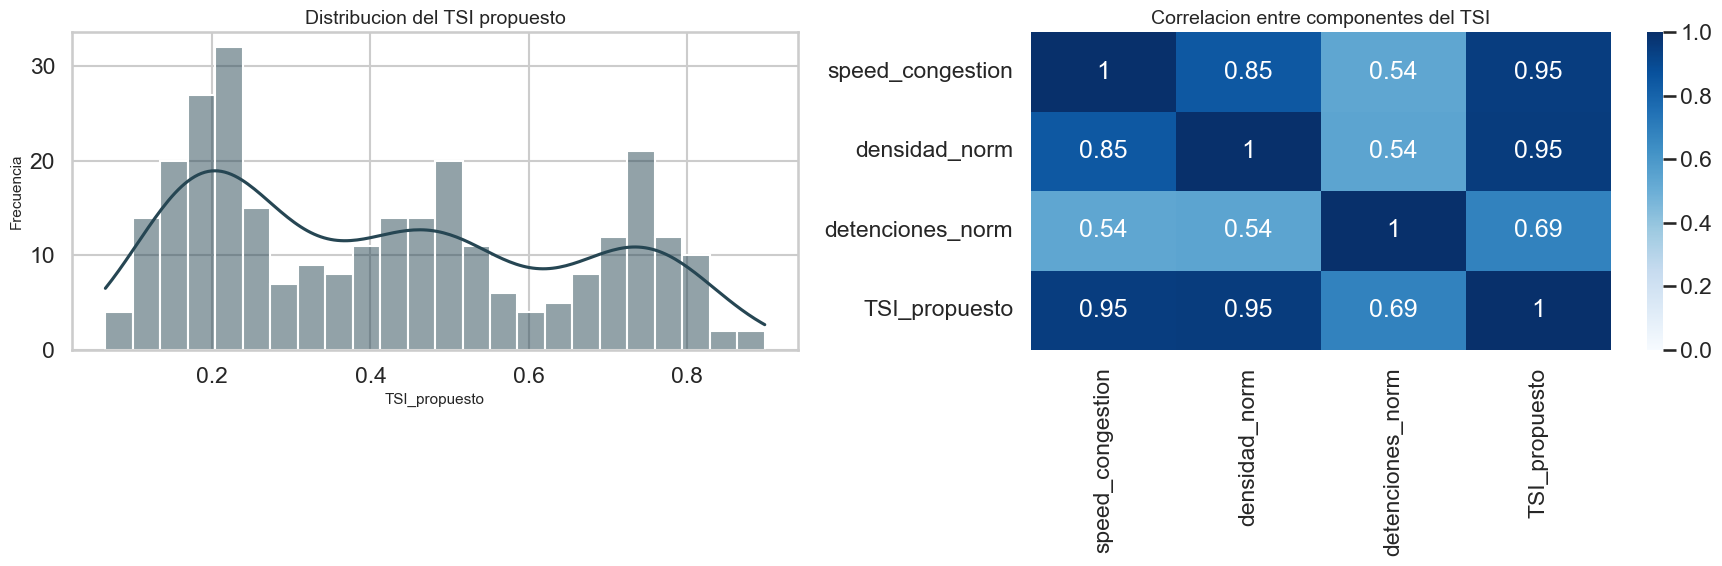

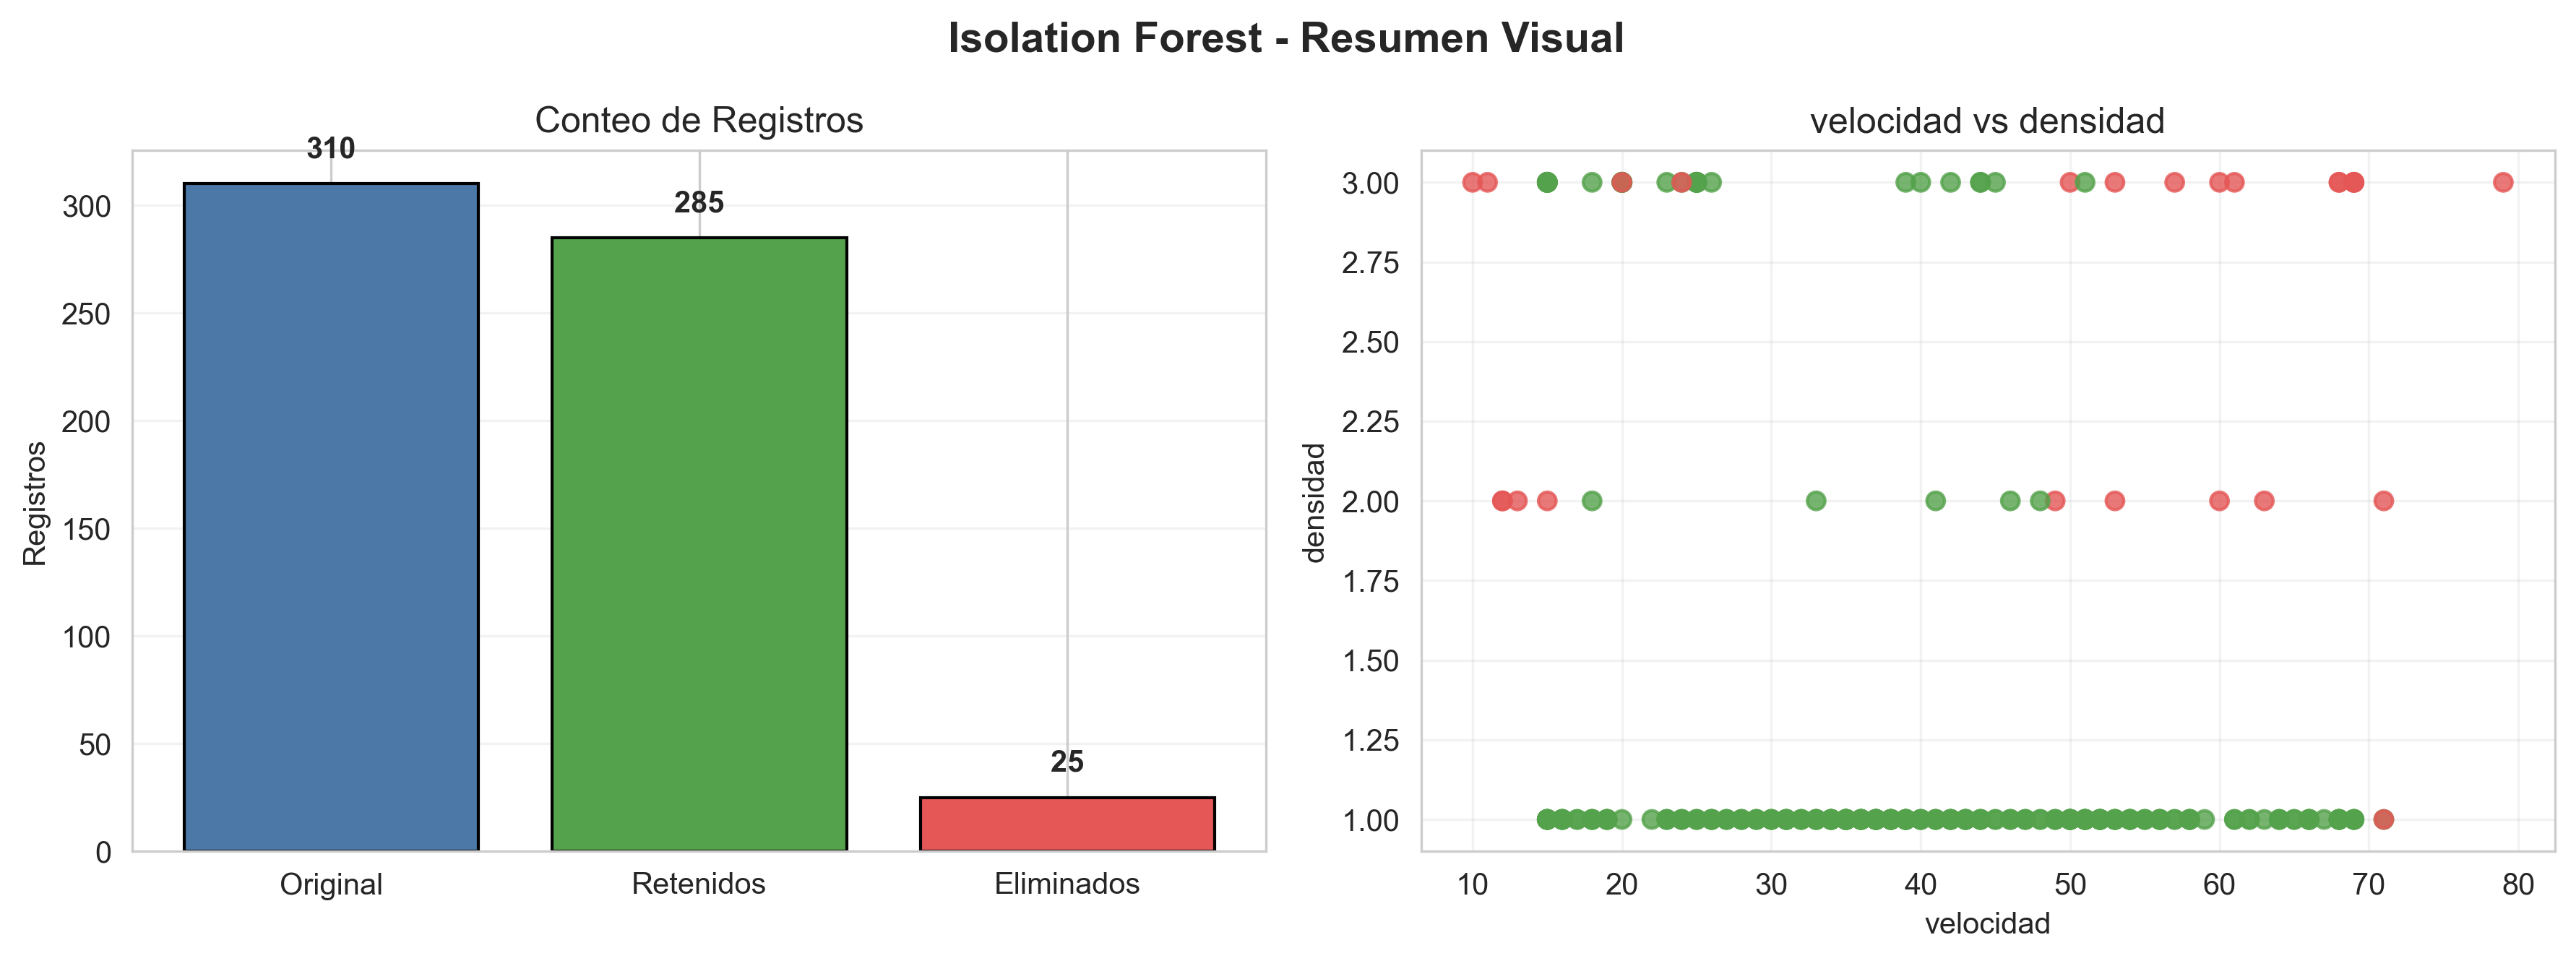

In [3]:
source_df['TSI_propuesto'] = (
    0.45 * source_df['speed_congestion'] +
    0.35 * source_df['densidad_norm'] +
    0.20 * source_df['detenciones_norm']
).clip(0, 1)

tsi_stats = source_df['TSI_propuesto'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print('TSI = 0.45 * speed_congestion + 0.35 * densidad_norm + 0.20 * detenciones_norm')
if 'TSI' in source_df.columns:
    print(f'Correlacion con el TSI actual: {source_df["TSI"].corr(source_df["TSI_propuesto"]):.4f}')
print()
print(tsi_stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.histplot(source_df['TSI_propuesto'], bins=24, kde=True, ax=axes[0], color='#264653')
axes[0].set_title('Distribucion del TSI propuesto')
axes[0].set_xlabel('TSI_propuesto')
axes[0].set_ylabel('Frecuencia')

corr_frame = source_df[['speed_congestion', 'densidad_norm', 'detenciones_norm', 'TSI_propuesto']].corr()
sns.heatmap(corr_frame, annot=True, cmap='Blues', vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Correlacion entre componentes del TSI')
plt.tight_layout()
plt.show()

if IF_SUMMARY_IMAGE.exists():
    display(Image(filename=str(IF_SUMMARY_IMAGE)))
elif IF_BOXPLOTS_IMAGE.exists():
    display(Image(filename=str(IF_BOXPLOTS_IMAGE)))

## 4. Señal estructural de DBSCAN

DBSCAN se revisa como estructura principal porque no solo filtra, sino que separa regímenes densos con ruido moderado.

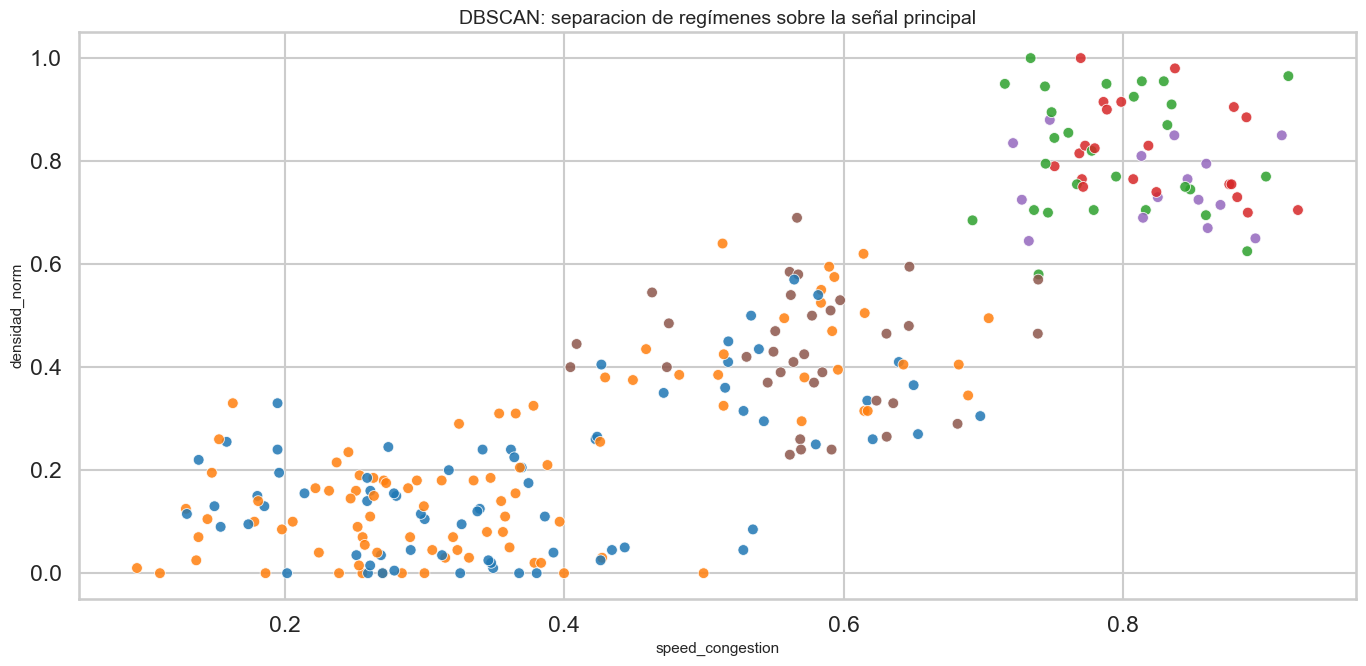

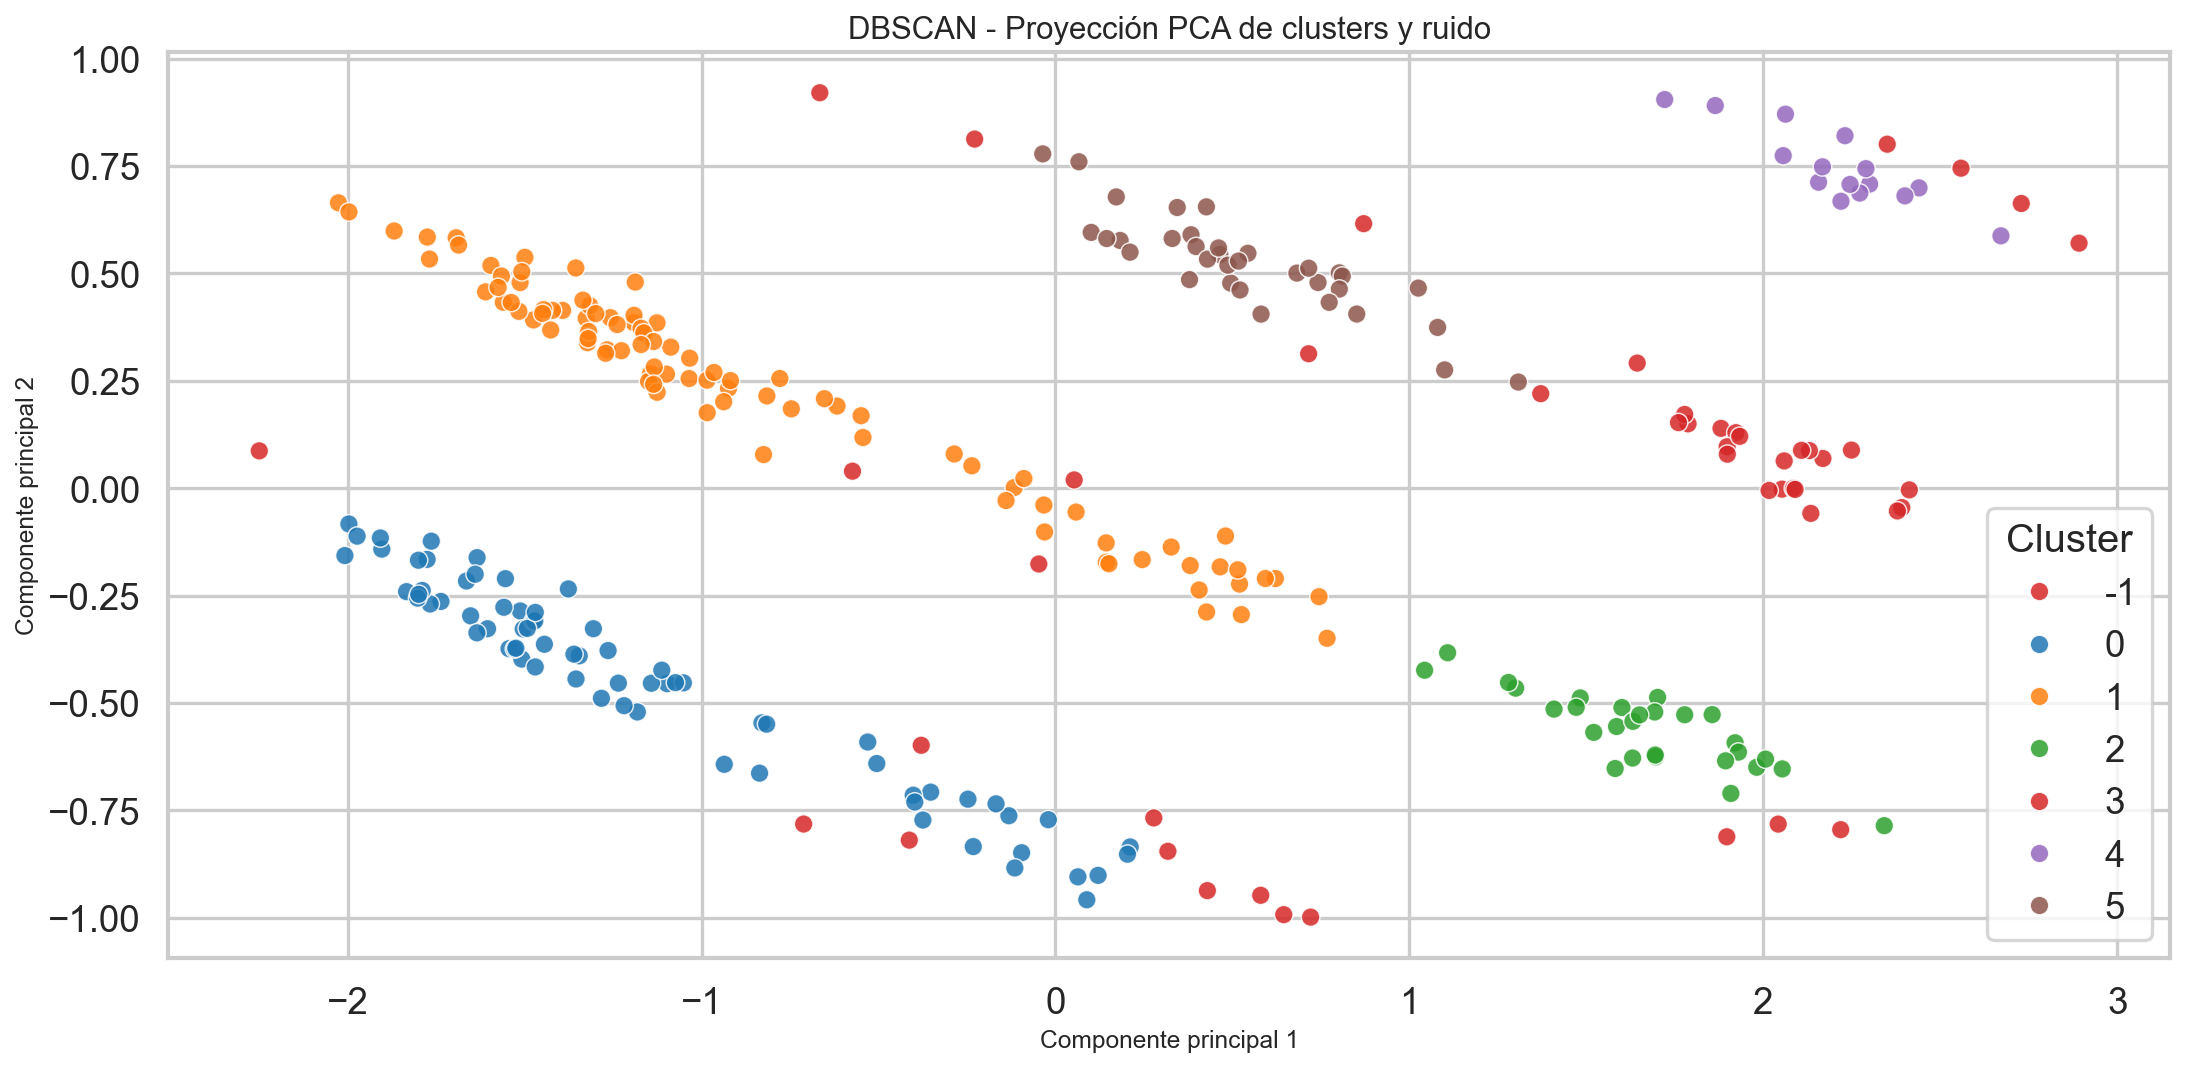

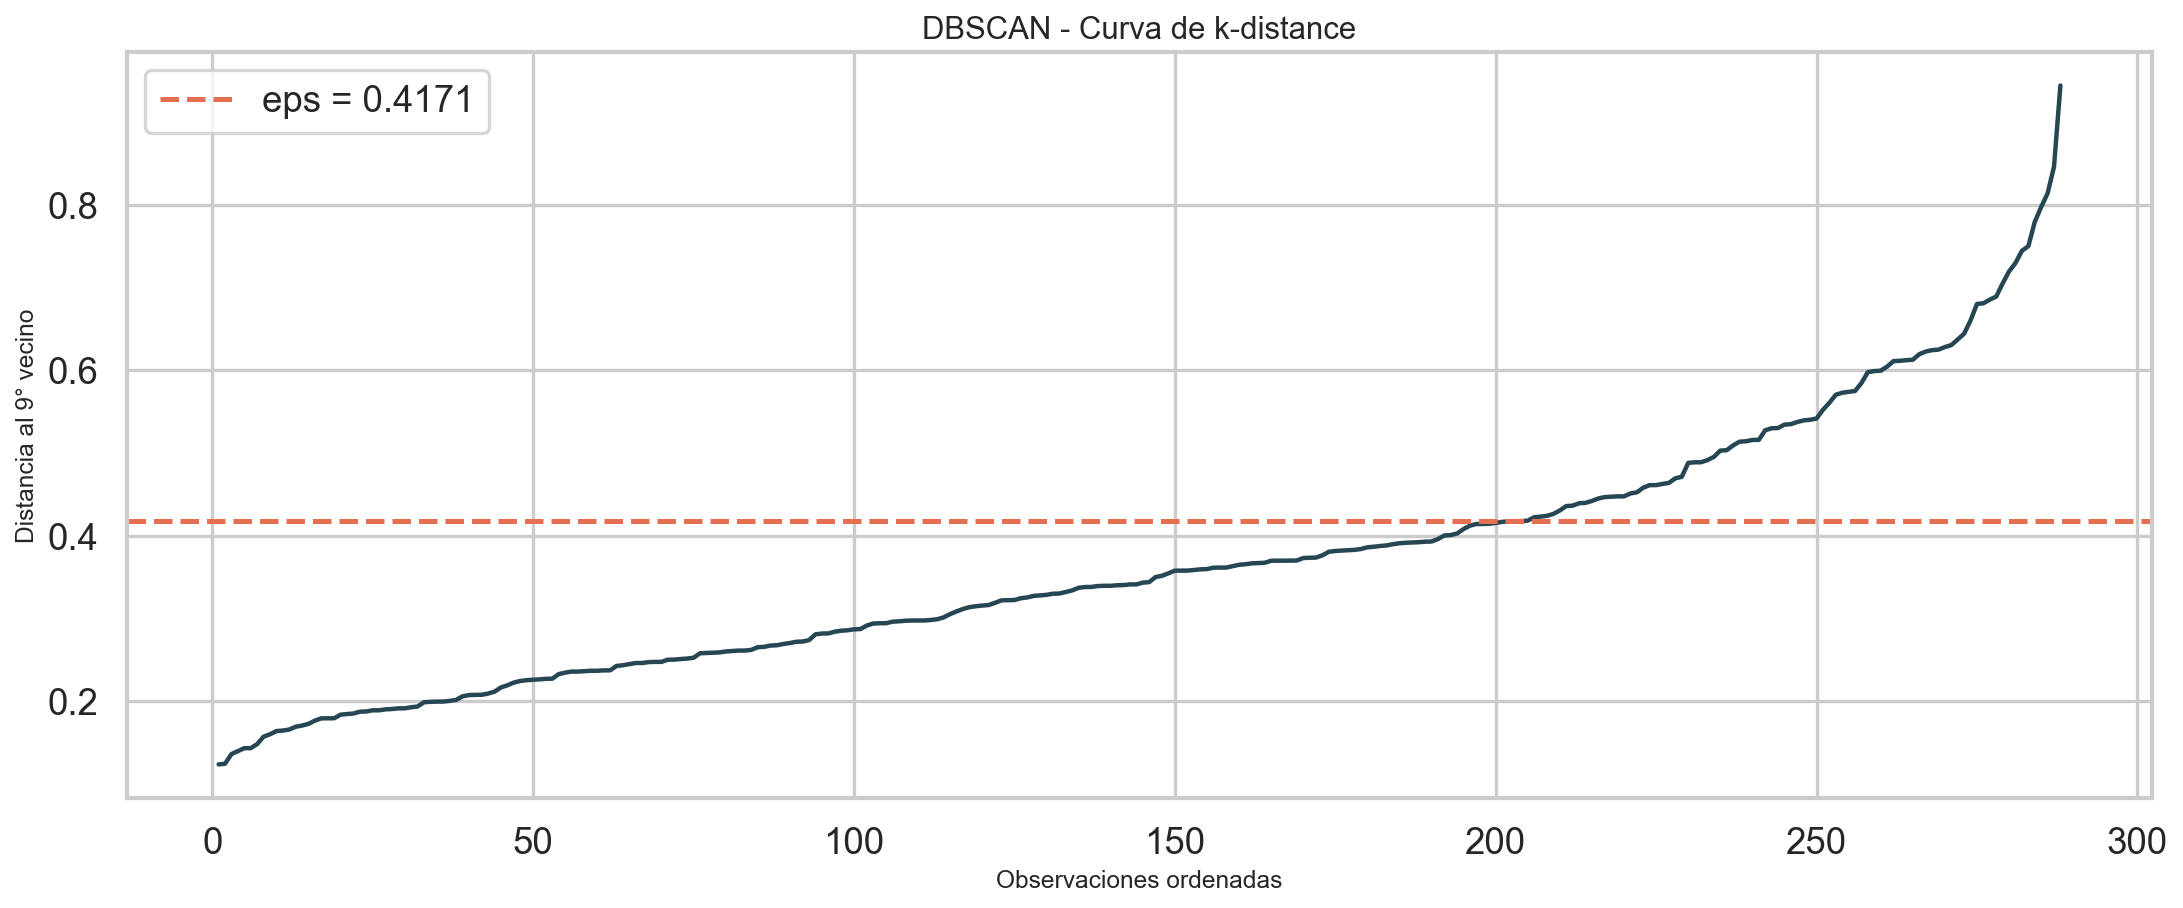

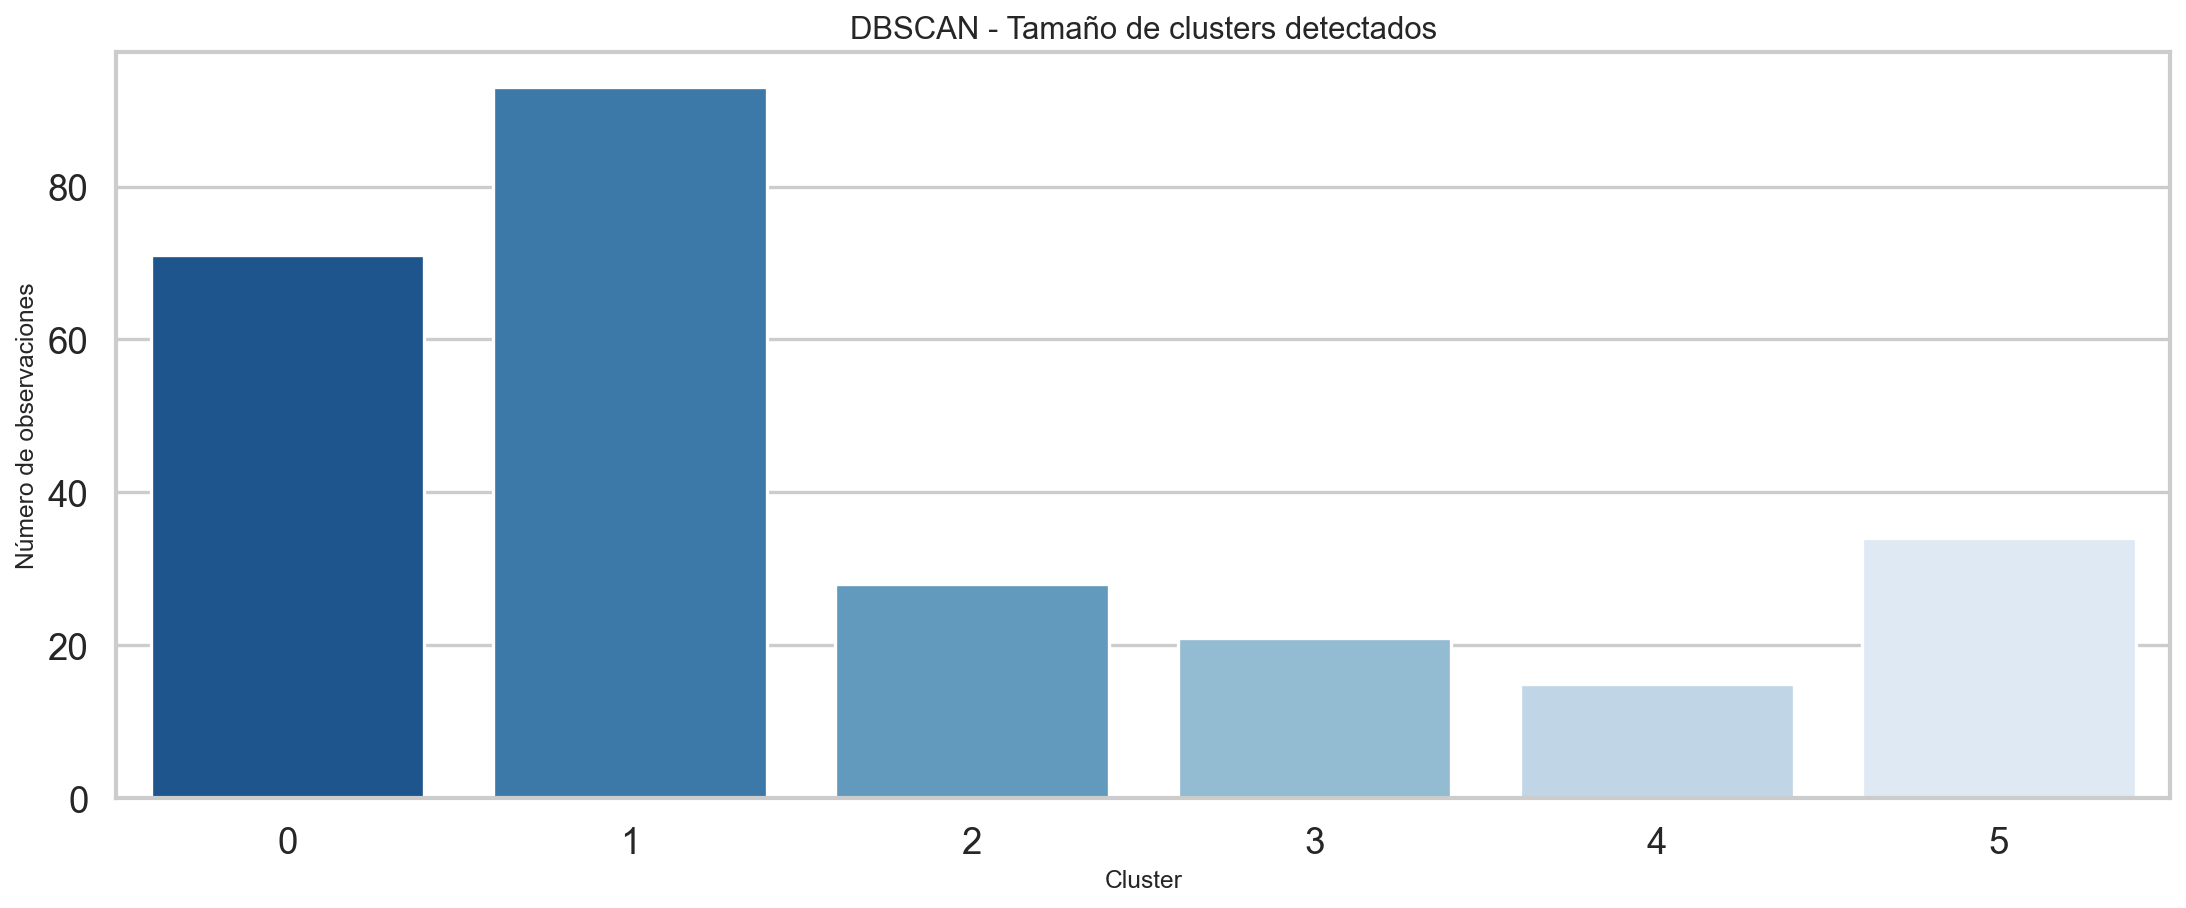

In [4]:
if dbscan_df is None:
    raise FileNotFoundError('No se encontro filtered_dbscan.csv')

fig, ax = plt.subplots(figsize=(14, 7))
sns.scatterplot(
    data=dbscan_df,
    x='speed_congestion',
    y='densidad_norm',
    hue='dbscan_cluster',
    palette='tab10',
    s=60,
    alpha=0.85,
    ax=ax,
    legend=False,
)
ax.set_title('DBSCAN: separacion de regímenes sobre la señal principal')
ax.set_xlabel('speed_congestion')
ax.set_ylabel('densidad_norm')
plt.tight_layout()
plt.show()

if DBSCAN_PCA_IMAGE.exists():
    display(Image(filename=str(DBSCAN_PCA_IMAGE)))
if DBSCAN_KDIST_IMAGE.exists():
    display(Image(filename=str(DBSCAN_KDIST_IMAGE)))
if DBSCAN_CLUSTER_IMAGE.exists():
    display(Image(filename=str(DBSCAN_CLUSTER_IMAGE)))

## 5. Cierre tecnico

El notebook deja una ruta corta de uso: cargar artefactos finales, comparar algoritmos, revisar el TSI y consultar la estructura de DBSCAN como soporte de la interpretacion final.